1. load the dataset

In [8]:
import pandas as pd

df_clean=pd.read_csv("DS2_commodity_prices_10yr.csv")

print(df.head())
print(df.info())
print(df.describe())

         date  commodity      open      high       low     close  volume  \
0  2014-01-02  Steel_HRC  598.5489  602.7788  595.2943  598.4254    1109   
1  2014-01-03  Steel_HRC  573.8080  578.2438  572.2654  574.4014     796   
2  2014-01-06  Steel_HRC  575.2184  579.4599  573.8479  576.0968    2226   
3  2014-01-07  Steel_HRC  577.8701  583.5032  572.4176  579.1640    3756   
4  2014-01-08  Steel_HRC  576.7604  577.6070  571.7317  575.7011     322   

   daily_return  return_5d  return_21d  ...  sma_63  bollinger_upper  \
0           NaN        NaN         NaN  ...     NaN              NaN   
1     -0.040973        NaN         NaN  ...     NaN              NaN   
2      0.002947        NaN         NaN  ...     NaN              NaN   
3      0.005310        NaN         NaN  ...     NaN              NaN   
4     -0.005997        NaN         NaN  ...     NaN              NaN   

   bollinger_lower  bollinger_z  rsi_14      macd  macd_signal  momentum_10d  \
0              NaN          Na

2.Check Missing Values

In [9]:
print(df_clean.isnull().sum())

date                    0
commodity               0
open                    0
high                    0
low                     0
close                   0
volume                  0
daily_return            8
return_5d              40
return_21d            168
volatility_5d_ann      40
volatility_21d_ann    168
volatility_63d_ann    504
sma_21                160
sma_63                496
bollinger_upper       160
bollinger_lower       160
bollinger_z           496
rsi_14                112
macd                    0
macd_signal             0
momentum_10d           80
momentum_21d          168
term_spread             0
dtype: int64


In [10]:
df = df_clean.dropna()

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (22448, 24)
Cleaned Shape: (22952, 24)


In [7]:
print(df_clean.isnull().sum())

date                  0
commodity             0
open                  0
high                  0
low                   0
close                 0
volume                0
daily_return          0
return_5d             0
return_21d            0
volatility_5d_ann     0
volatility_21d_ann    0
volatility_63d_ann    0
sma_21                0
sma_63                0
bollinger_upper       0
bollinger_lower       0
bollinger_z           0
rsi_14                0
macd                  0
macd_signal           0
momentum_10d          0
momentum_21d          0
term_spread           0
dtype: int64


Average price by commodity

In [11]:
df=pd.read_csv("DS2_commodity_prices_10yr.csv")

df.groupby('commodity')['close'].mean()


commodity
Aluminium         2282.659340
Cobalt_Index        69.077498
Copper               3.839271
Iron_Ore            90.550623
Lithium_ETF         84.304638
Nickel           24481.541322
RareEarth_ETF       41.621797
Steel_HRC          686.361667
Name: close, dtype: float64

Highest priced commodity

In [12]:
df.groupby('commodity')['close'].max()

commodity
Aluminium         3363.2414
Cobalt_Index       133.0949
Copper               6.4342
Iron_Ore           143.0554
Lithium_ETF        159.0687
Nickel           39289.9051
RareEarth_ETF      102.4359
Steel_HRC         1144.4298
Name: close, dtype: float64

Average daily return


In [13]:
df.groupby('commodity')['daily_return'].mean()

commodity
Aluminium        0.000033
Cobalt_Index     0.000169
Copper           0.000078
Iron_Ore        -0.000090
Lithium_ETF      0.000229
Nickel           0.000127
RareEarth_ETF   -0.000051
Steel_HRC       -0.000047
Name: daily_return, dtype: float64

Most volatile commodity

In [14]:
df.groupby('commodity')['volatility_21d_ann'].mean()


commodity
Aluminium        0.238860
Cobalt_Index     0.313091
Copper           0.247463
Iron_Ore         0.320281
Lithium_ETF      0.393307
Nickel           0.338700
RareEarth_ETF    0.431192
Steel_HRC        0.283526
Name: volatility_21d_ann, dtype: float64

Largest one-day gain


In [16]:

df.nlargest(10,'daily_return')


,date,commodity,open,high,low,close,volume,daily_return,return_5d,return_21d,...,sma_63,bollinger_upper,bollinger_lower,bollinger_z,rsi_14,macd,macd_signal,momentum_10d,momentum_21d,term_spread
19566,2023-01-09,RareEarth_ETF,21.7341,21.7766,21.6291,21.7337,609,0.086673,0.073360,-0.047611,...,22.140567,21.985334,19.165590,-0.261023,52.331238,-0.556449,-0.638530,0.033408,-0.046496,8.384375
18509,2018-12-20,RareEarth_ETF,72.2857,72.4250,71.5510,72.1571,1948,0.086070,0.145473,0.192649,...,54.628013,68.302737,53.692663,3.066117,72.595649,3.035070,2.222880,0.264525,0.212457,-0.191515
17444,2014-11-20,RareEarth_ETF,48.7565,48.9413,48.4931,48.6981,607,0.083200,0.007091,-0.104917,...,52.522751,58.769301,44.213051,-0.978407,41.366755,-2.026835,-1.292428,-0.070824,-0.099601,8.171387
12750,2018-11-21,Lithium_ETF,67.9970,68.7993,67.9104,68.1524,3809,0.081673,0.087247,0.066713,...,60.850954,66.800359,57.324937,2.988927,63.308294,0.765314,0.495356,0.125526,0.068989,2.170105
17247,2014-02-18,RareEarth_ETF,59.6624,60.1648,59.4066,59.7553,4596,0.080419,0.029813,0.031755,...,NaN,61.100645,54.465346,NaN,50.304737,-0.308872,-0.267831,0.064224,0.032264,3.014848
13959,2023-07-11,Lithium_ETF,146.9022,148.0621,145.9502,147.0184,4718,0.080330,0.035654,-0.031209,...,142.023344,157.570837,133.115125,0.478077,52.120009,-1.774516,-0.931007,0.036273,-0.030727,7.862482
18376,2018-06-18,RareEarth_ETF,78.8608,79.7153,78.6964,79.0292,3836,0.079820,0.000913,0.098514,...,72.369975,84.304201,69.385847,1.087219,56.157629,1.105698,1.629817,-0.009946,0.103530,0.772289
19612,2023-03-14,RareEarth_ETF,19.2579,19.4243,19.1087,19.2042,1118,0.078811,0.038104,0.022273,...,19.293578,18.942674,16.047240,-0.054506,65.719527,-0.152965,-0.412271,0.089291,0.022523,-2.470429
13605,2022-03-02,Lithium_ETF,100.6178,100.9586,99.7180,100.3625,920,0.078454,0.097731,0.191274,...,91.183419,98.099749,82.218374,1.427101,74.343983,1.863116,1.151433,0.108385,0.210791,1.976251
19535,2022-11-25,RareEarth_ETF,25.4706,25.6375,25.3886,25.5308,752,0.078452,0.171926,0.080917,...,23.200343,24.333354,20.150322,1.691402,76.854503,0.205394,-0.192356,0.132141,0.084281,-7.205518


Largest one-day loss


In [17]:
df.nsmallest(10,'daily_return')


,date,commodity,open,high,low,close,volume,daily_return,return_5d,return_21d,...,sma_63,bollinger_upper,bollinger_lower,bollinger_z,rsi_14,macd,macd_signal,momentum_10d,momentum_21d,term_spread
12094,2016-05-17,Lithium_ETF,87.2730,87.9197,86.9215,87.1248,1648,-0.109976,-0.174945,-0.121132,...,99.190429,108.410918,91.722130,-2.805043,28.140080,-0.710911,0.633187,-0.123389,-0.114083,-0.052176
17694,2015-11-05,RareEarth_ETF,43.8105,44.1149,43.4734,43.9212,3518,-0.109037,-0.109801,-0.121781,...,48.560163,52.057481,43.972596,-2.505623,37.234430,-0.524144,-0.426370,-0.048649,-0.114658,-12.441380
19185,2021-07-23,RareEarth_ETF,29.8980,30.1073,29.6853,29.9525,1242,-0.095403,-0.138516,-0.401762,...,43.857841,45.617070,30.278388,-2.711285,17.918577,-3.154528,-2.613252,-0.201167,-0.330860,-10.031474
19546,2022-12-12,RareEarth_ETF,20.8394,20.9066,20.8121,20.8508,976,-0.089083,-0.157543,-0.078383,...,23.253935,25.908381,20.412714,-1.658262,38.070054,0.023933,0.292840,-0.142958,-0.075389,-5.428633
18387,2018-07-03,RareEarth_ETF,65.2922,65.5101,64.6992,65.1591,2115,-0.087442,-0.099344,-0.202981,...,73.803044,85.154638,67.060143,-1.599621,32.043498,-1.693901,-0.444143,-0.168137,-0.183706,-1.399989
13780,2022-11-02,Lithium_ETF,90.4261,91.3089,89.9240,90.4398,3654,-0.084404,-0.224184,-0.261336,...,113.471056,131.044119,96.602281,-3.712368,16.415187,-4.517134,-1.699720,-0.240501,-0.229978,-13.328115
18979,2020-10-08,RareEarth_ETF,48.6117,49.0056,48.4674,48.6554,2194,-0.083714,-0.214511,-0.000220,...,50.865303,62.583747,47.647025,-0.558003,35.686203,1.114319,2.092246,-0.104816,-0.000220,1.852456
18812,2020-02-18,RareEarth_ETF,39.8481,40.0853,39.7833,39.8776,2643,-0.083416,-0.103726,-0.225714,...,50.390408,52.096475,40.262668,-2.598038,13.006741,-2.168951,-1.828246,-0.140849,-0.202054,-5.607580
19614,2023-03-16,RareEarth_ETF,17.9199,18.0263,17.8285,17.9204,4282,-0.082468,0.000006,0.024270,...,19.243083,19.147423,15.947615,-0.807468,57.872360,-0.030610,-0.272464,0.069358,0.024567,-4.089133
20478,2015-07-09,Iron_Ore,79.6530,80.4337,78.9641,79.7238,2393,-0.082360,-0.081824,-0.200890,...,98.099900,96.534661,78.656253,-2.058827,30.899614,-3.653549,-3.753173,-0.033651,-0.181998,-6.573404


 RSI Overbought Signals


In [19]:

(df['rsi_14']>70).sum()


2955

 RSI Oversold Signals


In [21]:
(df['rsi_14']<30).sum()


2757

Average volume


In [23]:
df.groupby('commodity')['volume'].mean()


commodity
Aluminium        2523.455908
Cobalt_Index     2552.093761
Copper           2478.428372
Iron_Ore         2520.685256
Lithium_ETF      2499.060648
Nickel           2484.958174
RareEarth_ETF    2479.878006
Steel_HRC        2530.010108
Name: volume, dtype: float64

Highest Bollinger Z-score


In [24]:
df[['commodity','bollinger_z']]\
.sort_values('bollinger_z',ascending=False)


,commodity,bollinger_z
13891,Lithium_ETF,3.925852
11705,Lithium_ETF,3.897826
1788,Steel_HRC,3.863632
13890,Lithium_ETF,3.739495
16189,Cobalt_Index,3.705109
...,...,...
20140,Iron_Ore,NaN
20141,Iron_Ore,NaN
20142,Iron_Ore,NaN
20143,Iron_Ore,NaN


Annual return


In [25]:
df['date']=pd.to_datetime(df['date'])

df.groupby(df['date'].dt.year)['daily_return'].sum()


date
2014    2.391412
2015   -1.368253
2016   -0.684703
2017   -1.113863
2018    1.851198
2019   -0.380584
2020    0.097032
2021   -0.879006
2022   -0.267974
2023    2.071076
2024   -0.433626
Name: daily_return, dtype: float64

MACD positive days


In [26]:
df['date']=pd.to_datetime(df['date'])

df.groupby(df['date'].dt.year)['daily_return'].sum()


date
2014    2.391412
2015   -1.368253
2016   -0.684703
2017   -1.113863
2018    1.851198
2019   -0.380584
2020    0.097032
2021   -0.879006
2022   -0.267974
2023    2.071076
2024   -0.433626
Name: daily_return, dtype: float64

Commodity Sharpe Ratio


In [27]:

df.groupby('commodity')['daily_return'].mean() / \
df.groupby('commodity')['daily_return'].std()


commodity
Aluminium        0.002196
Cobalt_Index     0.008418
Copper           0.004910
Iron_Ore        -0.004430
Lithium_ETF      0.009111
Nickel           0.005878
RareEarth_ETF   -0.001854
Steel_HRC       -0.002580
Name: daily_return, dtype: float64

Maximum Drawdown


In [28]:

cum=(1+df['daily_return'].fillna(0)).cumprod()

drawdown=(cum/cum.cummax())-1

drawdown.min()

-0.9879449706523122

Average Closing Price by Commodity




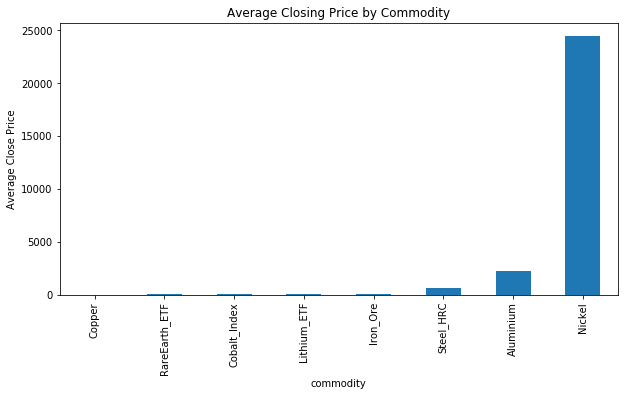

In [30]:


import matplotlib.pyplot as plt

avg_price = df.groupby('commodity')['close'].mean().sort_values()

avg_price.plot(kind='bar', figsize=(10,5))
plt.title("Average Closing Price by Commodity")
plt.ylabel("Average Close Price")
plt.show()

Commodity Price Trend Over Time


c:\program files\python37\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\program files\python37\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\program files\python37\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will 

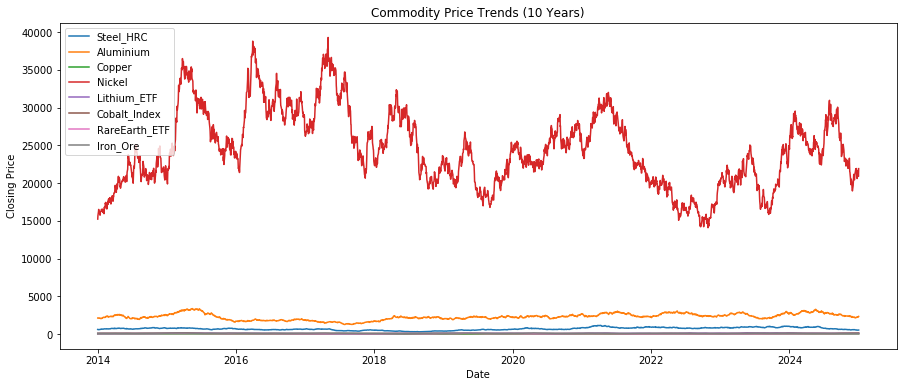

In [31]:


plt.figure(figsize=(15,6))

for commodity in df['commodity'].unique():
    subset = df[df['commodity']==commodity]
    plt.plot(subset['date'], subset['close'], label=commodity)

plt.title("Commodity Price Trends (10 Years)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

Volatility Comparison


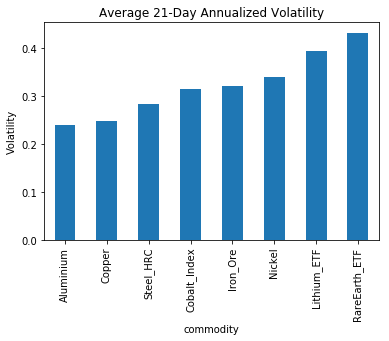

In [32]:


volatility = df.groupby('commodity')['volatility_21d_ann'].mean()

volatility.sort_values().plot(kind='bar')
plt.title("Average 21-Day Annualized Volatility")
plt.ylabel("Volatility")
plt.show()

Daily Return Distribution


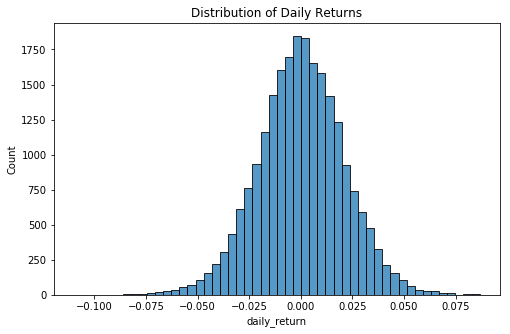

In [33]:

import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['daily_return'].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

rading Volume by Commodity


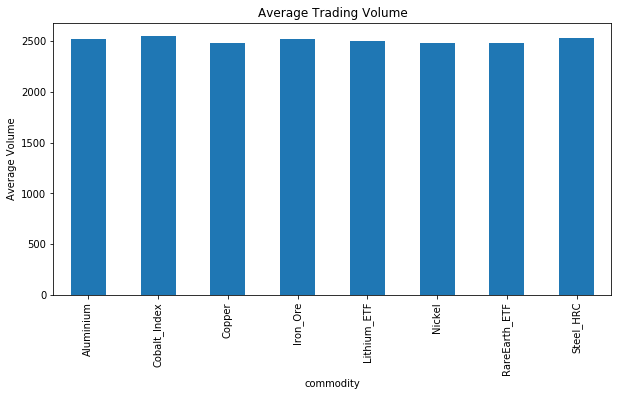

In [34]:
volume = df.groupby('commodity')['volume'].mean()

volume.plot(kind='bar', figsize=(10,5))
plt.title("Average Trading Volume")
plt.ylabel("Average Volume")
plt.show()

Correlation Heatmap


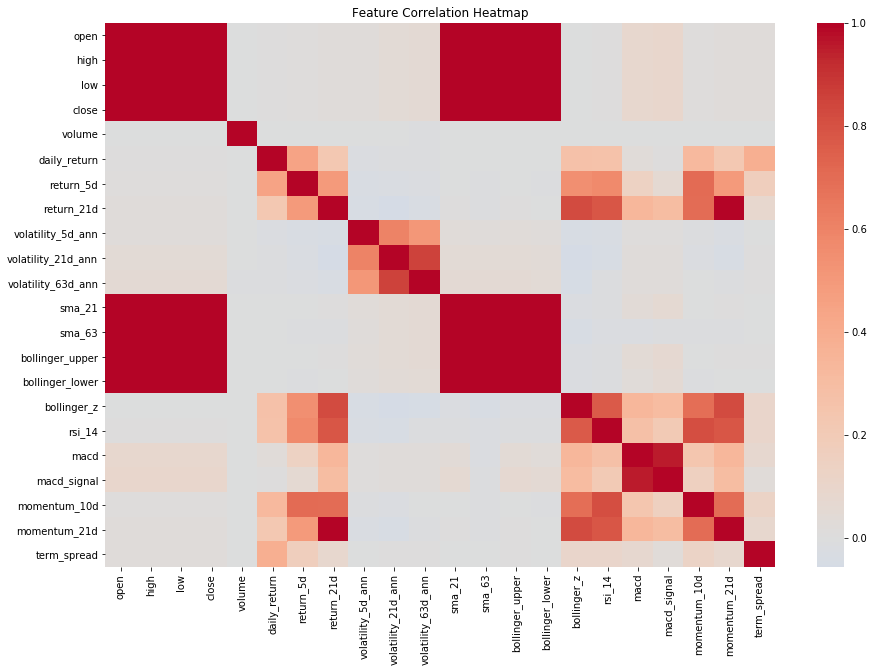

In [35]:

import seaborn as sns

numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(15,10))
sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()

RSI Overbought vs Oversold Analysis


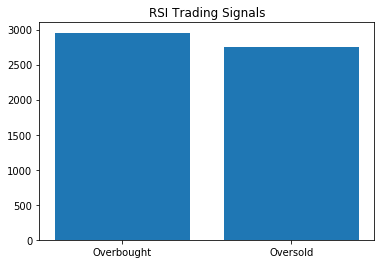

In [36]:
signals = [
    (df['rsi_14']>70).sum(),
    (df['rsi_14']<30).sum()
]

plt.figure(figsize=(6,4))
plt.bar(['Overbought','Oversold'],signals)
plt.title("RSI Trading Signals")
plt.show()

Bollinger Z-Score Distribution


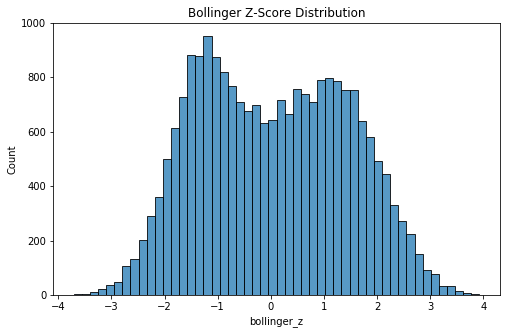

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['bollinger_z'].dropna(), bins=50)
plt.title("Bollinger Z-Score Distribution")
plt.show()

Annual Commodity Market Performance


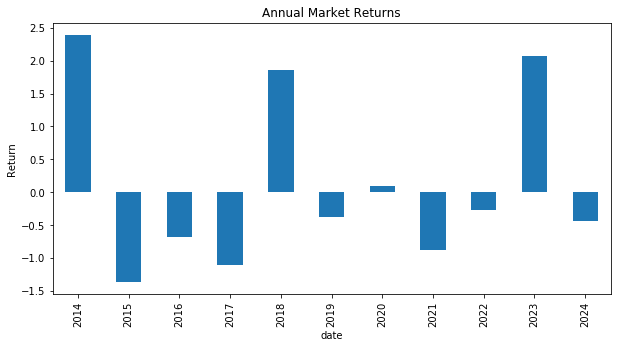

In [38]:

annual_return = df.groupby(df['date'].dt.year)['daily_return'].sum()

annual_return.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Annual Market Returns")
plt.ylabel("Return")
plt.show()

Sharpe Ratio Comparison


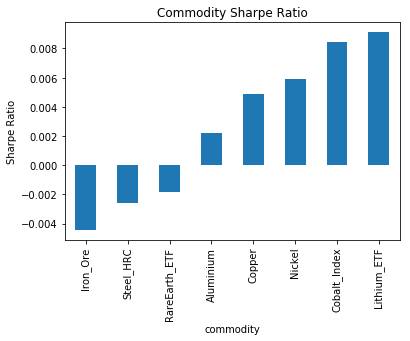

In [39]:
sharpe = (
    df.groupby('commodity')['daily_return'].mean()
    /
    df.groupby('commodity')['daily_return'].std()
)

sharpe.sort_values().plot(kind='bar')
plt.title("Commodity Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.show()

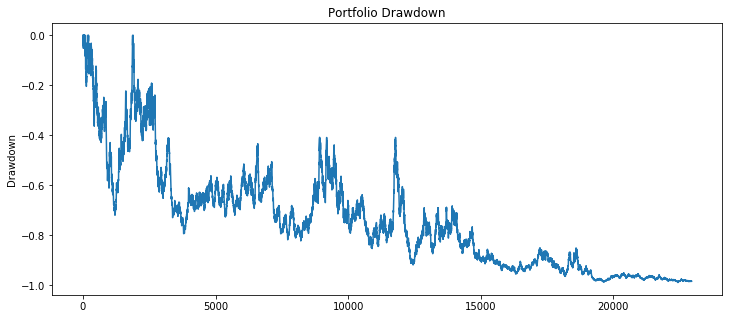

Maximum Drawdown: -0.9879449706523122


In [40]:
cum = (1 + df['daily_return'].fillna(0)).cumprod()

drawdown = (cum / cum.cummax()) - 1

plt.figure(figsize=(12,5))
plt.plot(drawdown)
plt.title("Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.show()

print("Maximum Drawdown:", drawdown.min())

Top 10 Largest Gains and Losses

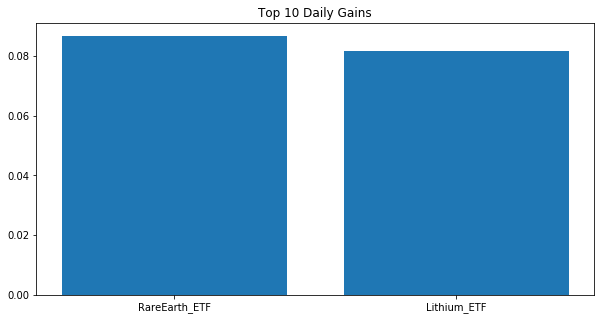

In [41]:
top_gains = df.nlargest(10,'daily_return')

plt.figure(figsize=(10,5))
plt.bar(top_gains['commodity'],
        top_gains['daily_return'])
plt.title("Top 10 Daily Gains")
plt.show()


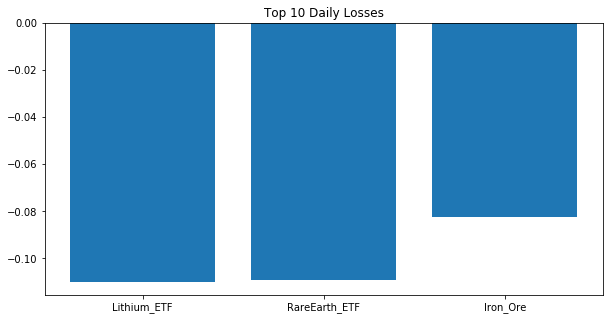

In [42]:
top_losses = df.nsmallest(10,'daily_return')

plt.figure(figsize=(10,5))
plt.bar(top_losses['commodity'],
        top_losses['daily_return'])
plt.title("Top 10 Daily Losses")
plt.show()